## Глава 5 - Сжатие данных путем уменьшения размерности 

In [1]:
from IPython.display import Image
# В главе 4 вы узнали о разнообразных подходах к уменьшению размерности набора данных с использованием
# различных методов выбора признаков. Альтернативным подходом к выбору признаков для уменьшения
# размерности является извлечение признаков (feature extraction). В этой главе говорится о двух
# фундаментальных методах, которые помогут вам сделать информационное наполнение набора данных более обобщенным,
# преобразовав его в новое подпространство объектов более низкой размерности, чем исходное.
# Сжатие данных занимает важное место в машинном обучении - оно помогает нам хранить и анализировать
# непрерывно растущие объемы данных, производимых и собираемых в эпоху передовых технологий.
# В этой главе будут рассмотрены следующие темы:
# ♦ метод главных компонент для сжатия данных без учителя;
# ♦ линейный дискриминантный анализ как метод уменьшения размерности с учителемvдля достижения максимальной
# разделимости классов;
# ♦ краткий обзор методов нелинейного уменьшения размерности и t-распределенного стохастического встраивания
# соседей для визуализации данных.

### 5.1. Уменьшение размерности без учителя с помощью метода главных компонент (Principal Component Analysis, РСА)

#### 5.1.1. Основные этапы метода главных компонент 

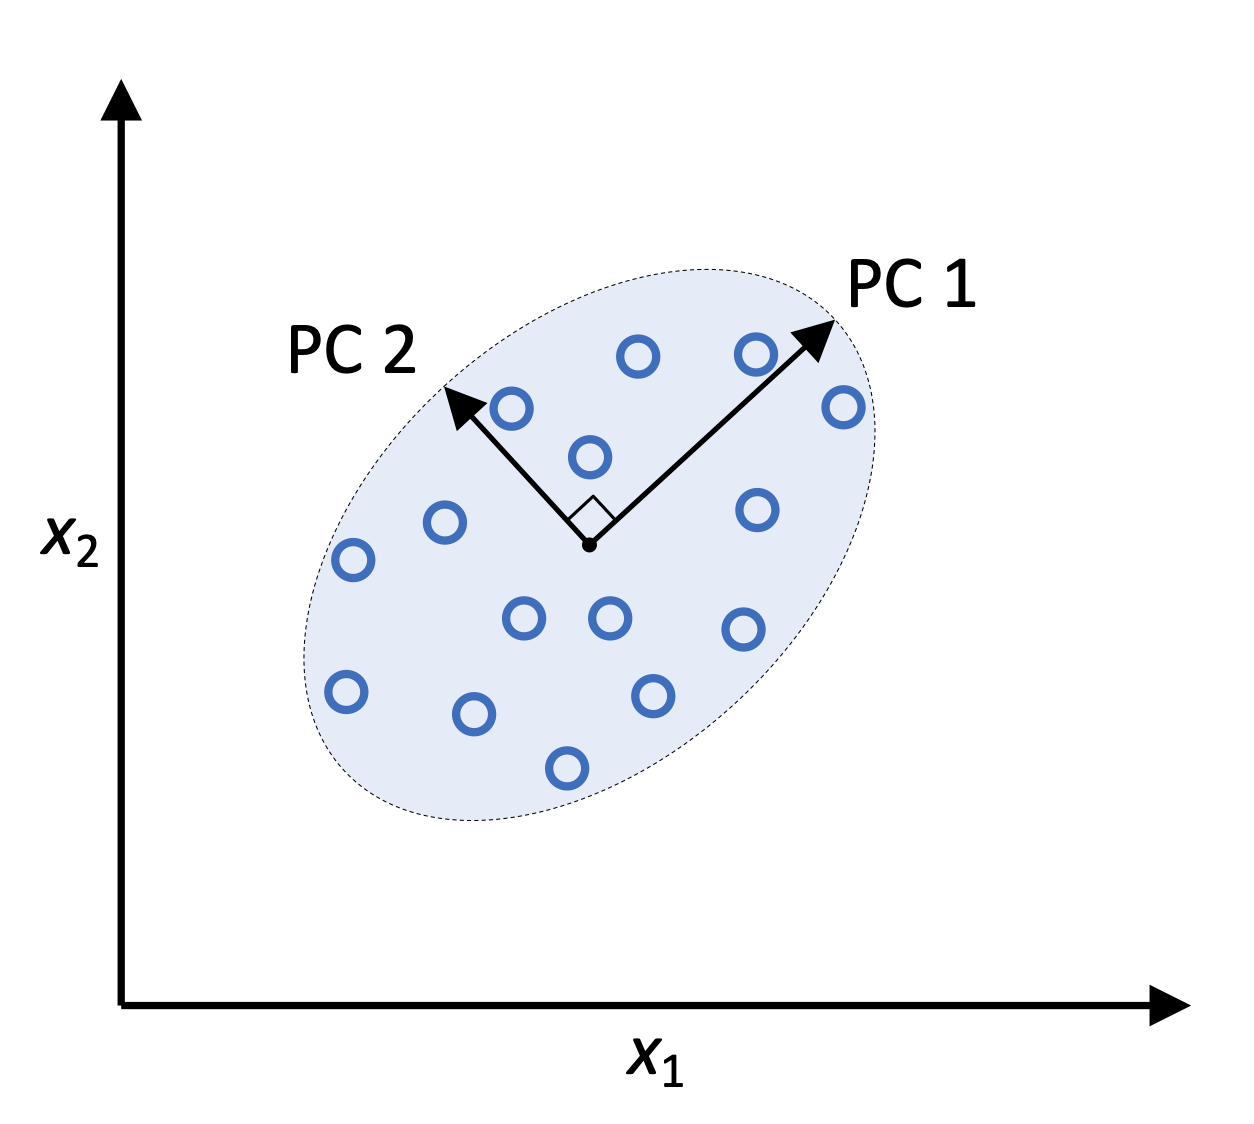

In [2]:
Image(filename='figures/05_01.png', width=400)
# Прежде чем более детально рассмотреть применение алгоритма РСА для уменьшения размерности,
# перечислим его основные шаги:
# 1. Стандартизируем d-мерный набор данных.
# 2. Строим ковариационную матрицу.
# 3. Раскладываем ковариационную матрицу на собственные векторы и собственные значения.
# 4. Сортируем собственные значения в порядке убывания, чтобы ранжировать соответствующие собственные векторы.
# 5. Выбираем k собственных векторов, которые соответствуют k наибольшим собственным значениям,
# где k- размерность нового подпространства признаков (k <= d).
# 6. Строим матрицу проекции W из «верхних» k собственных векторов.
# 7. Преобразовываем d-мерный входной набор данных Х, используя матрицу проекции W, чтобы получить новое
# k-мерное подпространство признаков.

#### 5.1.2. Пошаговый процесс извлечения основных компонент 

In [3]:
# Далее мы рассмотрим первые четыре шага алгоритма РСА:
# 1. Стандартизация данных.
# 2. Построение ковариационной матрицы.
# 3. Получение собственных значений и собственных векторов ковариационной матрицы.
# 4. Сортировка собственных значений по убыванию для ранжирования собственных
# векторов.
import pandas as pd
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)
df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines', 'Proline']
df_wine.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


<hr>

In [4]:
# Затем мы обработаем данные Wine, разделив их на обучающий и тестовый наборы данных, используя 70 и 30 %
# исходного набора данных соответственно, и стандартизируем их для единичной дисперсии:
from sklearn.model_selection import train_test_split
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3,
                     stratify=y,
                     random_state=0)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [5]:
# Собственные векторы ковариационной матрицы представляют главные компоненты (направления максимальной дисперсии),
# тогда как соответствующие собственные значения будут определять их величину.
# В случае набора данных Wine мы получили бы 13 собственных векторов и собственных значений из
# ковариационной матрицы размером 13х13.

# Далее, на третьем шаге получим собственные пары ковариационной матрицы.
import numpy as np
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

print('\nСобственные значения: \n', eigen_vals)
print('\nсобственные векторы \n', eigen_vecs)
# Функция nштру. linalg. eig была разработана для работы как с симметричными, так и с несимметричными
# квадратными матрицами. Однако вы можете обнаружить, что в некоторых случаях она возвращает
# комплексные собственные значения. Родственная ей функция nштру. linalg. eigh была реализована для декомпозиции
# герметовых матриц, что является численно более устойчивым подходом к работе с симметричными матрицами,
# такими как ковариационная матрица, - nштру.linalg. eigh всегда возвращает реальные собственные значения.


Собственные значения: 
 [4.84274532 2.41602459 1.54845825 0.96120438 0.84166161 0.6620634
 0.51828472 0.34650377 0.3131368  0.10754642 0.21357215 0.15362835
 0.1808613 ]

собственные векторы 
 [[-1.37242175e-01  5.03034778e-01 -1.37748734e-01 -3.29610003e-03
   2.90625226e-01 -2.99096847e-01 -7.90529293e-02  3.68176414e-01
   3.98377017e-01 -9.44869777e-02  3.74638877e-01 -1.27834515e-01
   2.62834263e-01]
 [ 2.47243265e-01  1.64871190e-01  9.61503863e-02  5.62646692e-01
  -8.95378697e-02 -6.27036396e-01  2.74002014e-01  1.25775752e-02
  -1.10458230e-01  2.63652406e-02 -1.37405597e-01  8.06401578e-02
  -2.66769211e-01]
 [-2.54515927e-02  2.44564761e-01  6.77775667e-01 -1.08977111e-01
   1.60834991e-01 -3.89128239e-04 -1.32328045e-01 -1.77578177e-01
  -3.82496856e-01  1.42747511e-01  4.61583035e-01  1.67924873e-02
  -1.15542548e-01]
 [ 2.06945084e-01 -1.13529045e-01  6.25040550e-01  3.38187002e-02
  -5.15873402e-02  4.05836452e-02 -2.23999097e-01  4.40592110e-01
   2.43373853e-01 -1.30

#### 5.1.3. Общая и объясненная дисперсия

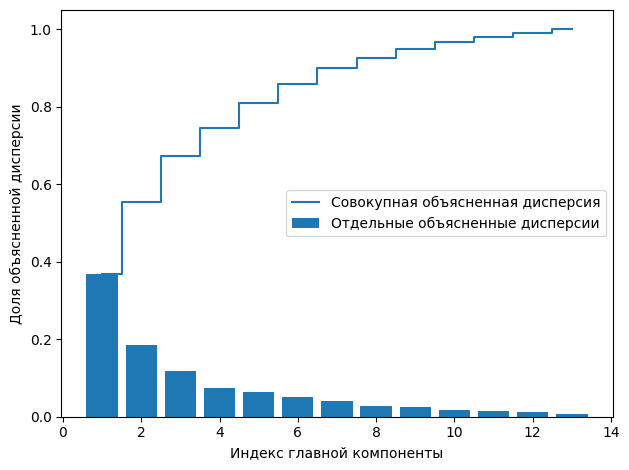

In [6]:
# Поскольку мы стремимся уменьшить размерность нашего набора данных, сжав его в новое подпространство признаков,
# то выбираем только такое подмножество собственных векторов (главных компонент), которое содержит большую часть
# информации (дисперсию). Собственные значения определяют величину собственных векторов, поэтому мы должны
# отсортировать собственные значения по убыванию величины, - нас интересуют лучшие k собственных векторов
# на основе величины их соответствующих собственных значений. Но прежде чем мы отберем эти k наиболее
# информативных собственных векторов, давайте построим для собственных значений графики доли
# объясненной дисперсии (variance explained ratio). Доля объясненной дисперсии собственного значения
# представляет собой просто частное собственного значения и полной суммы собственных значений:
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
import matplotlib.pyplot as plt
plt.bar(range(1, 14), var_exp, align='center',
        label='Отдельные объясненные дисперсии')
plt.step(range(1, 14), cum_var_exp, where='mid',
         label='Совокупная объясненная дисперсия')
plt.ylabel('Доля объясненной дисперсии')
plt.xlabel('Индекс главной компоненты')
plt.legend(loc='best')
plt.tight_layout()
plt.show()
# Хотя график объясненной дисперсии напоминает нам о значениях важности признаков, которые мы вычислили в
# главе 4 с помощью случайных лесов, нельзя забывать, что РСА - это метод без учителя, а это означает,
# что информация о метках классов игнорируется. В то время как случайный лес использует информацию о членстве
# в классе для вычисления примесей узлов, дисперсия просто измеряет разброс значений по оси признаков.

#### 5.1.4. Преобразование признаков 

In [7]:
# Выполнив разложение ковариационной матрицы на собственные пары, перейдем к последним трем шагам алгоритма,
# чтобы преобразовать набор данных Wine в новые оси главных компонент. В этом разделе нам осталось
# выполнить следующие шаги:
# 1. Выбрать k собственных векторов, которые соответствуют k наибольшим собственным значениям, где
# k- размерность нового подпространства признаков (k <= d).
# 2. Построить матрицу проекции W из «верхних» k собственных векторов.
# 3. Преобразовать d-мерный входной набор данных Х, используя матрицу проекции W,
# чтобы получить новое k-мерное подпространство признаков.

# Начнем с сортировки собственных пар по убыванию собственных значений:
# Создаем список пар (Собственные значения, Собственные вектора)
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]
# Сортируем пары (Собственные значения, Собственные вектора) по убыванию
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

# Затем соберем два собственных вектора, которые соответствуют двум самым большим собственным значениям,
# обеспечивающим около 60 % дисперсии в этом наборе данных. Нужно заметить, что для наглядности здесь мы
# берем только два собственных вектора, поскольку позже в этом разделе мы собираемся изобразить данные с помощью
# двумерной диаграммы рассеяния. На практике количество основных компонент должно определяться компромиссом
# между вычислительной эффективностью и производительностью классификатора:

w = np.hstack((eigen_pairs[0][1][:, np.newaxis],
               eigen_pairs[1][1][:, np.newaxis]))
print('Matrix W:\n', w)

Matrix W:
 [[-0.13724218  0.50303478]
 [ 0.24724326  0.16487119]
 [-0.02545159  0.24456476]
 [ 0.20694508 -0.11352904]
 [-0.15436582  0.28974518]
 [-0.39376952  0.05080104]
 [-0.41735106 -0.02287338]
 [ 0.30572896  0.09048885]
 [-0.30668347  0.00835233]
 [ 0.07554066  0.54977581]
 [-0.32613263 -0.20716433]
 [-0.36861022 -0.24902536]
 [-0.29669651  0.38022942]]


In [8]:
# Используя матрицу проекции , преобразуем экземпляр х (представленный в виде 13-мерного вектора-строки)
# в подпространство РСА (первая и вторая главные компоненты), получив х' - теперь уже двумерный вектор,
# состоящий из двух новых признаков:
X_train_std[0].dot(w)

array([2.38299011, 0.45458499])

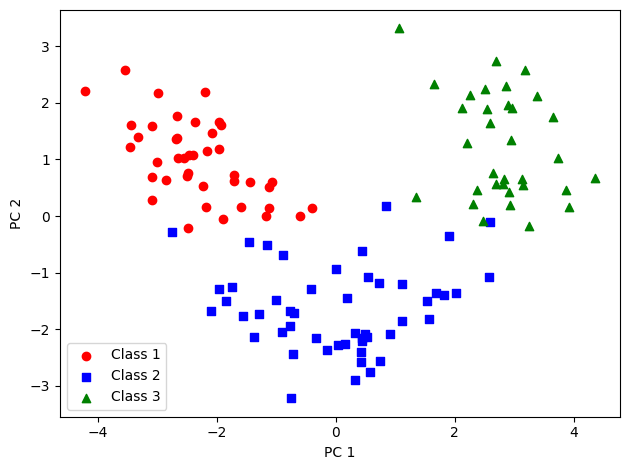

In [10]:
# Аналогичным образом мы можем преобразовать весь обучающий набор данных размером 124х 13 в две основные
# компоненты, вычислив скалярное произведение матриц.
# Наконец, визуализируем преобразованный обучающий набор данных Wine, который теперь хранится в виде
# двумерной матрицы 124 , построив двумерную диаграмму рассеяния
X_train_pca = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0],
                X_train_pca[y_train == l, 1],
                c=c, label=f'Class {l}', marker=m)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
# Хотя для наглядности на рис. 5 .3 мы отобразили информацию о метке класса, нужно
# помнить, что РСА - это метод без учителя, который не использует никакой информации о метке класса.

#### 5.1.5. Анализ основных компонент в scikit-learn

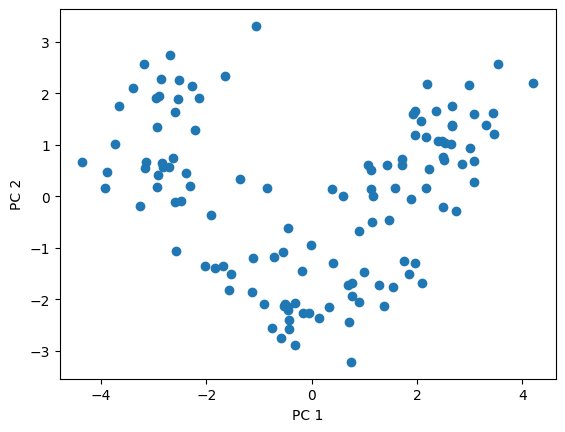

In [12]:
# Класс РСА- это еще один класс преобразователя scikit-leam, с помощью которого мы сначала обучаем модель,
# используя обучающие данные, прежде чем преобразовывать как обучающие данные, так и набор тестовых данных,
# задействуя одни и те же параметры модели. Теперь применим класс РСА из scikit-leam к обучающему набору данных
# Wine, классифицируем преобразованные примеры с помощью логистической регрессии и визуализируем области
# принятия решений с помощью функции plot_decision_regions, которую мы определили в главе 2

# Код для визуализации решающей границы как в главе 2
from matplotlib.colors import ListedColormap
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1])
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

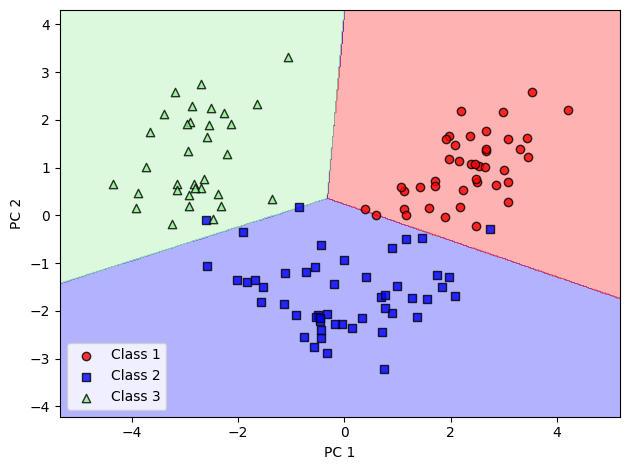

In [13]:
# обучение модели логистической регрессии на новом наборе
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
base_lr = LogisticRegression(random_state=1, solver='lbfgs')
lr = OneVsRestClassifier(base_lr)
lr = lr.fit(X_train_pca, y_train)

plot_decision_regions(X_train_pca, y_train, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

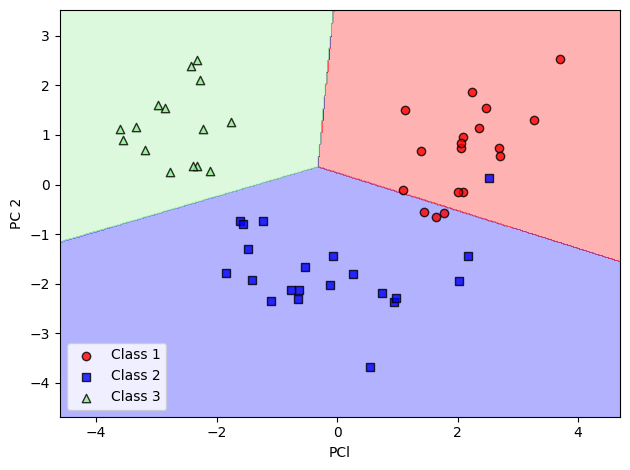

In [14]:
# Для полноты картины давайте нанесем области принятия
# решений логистической регрессии на преобразованный набор тестовых данных, чтобы
# увидеть, может ли модель хорошо разделить классы
plot_decision_regions(X_test_pca, y_test, classifier=lr)
plt.xlabel('РСl')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()
# Если нас интересуют доли объясненной дисперсии различных главных компонент, мы
# можем просто инициализировать класс РСА с параметром n_components=None, чтобы все
# главные компоненты были сохранены, а затем получить доступ к доле объясненной
# дисперсии через атрибут explained_variance_ratio_


#### 5.1.6. Оценка вклада признаков 

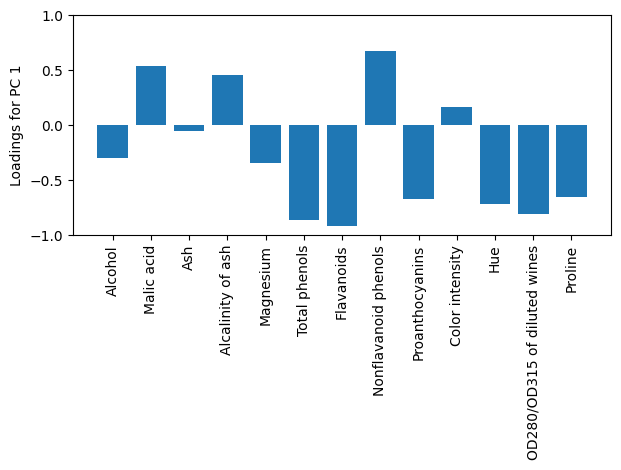

array([-0.3020184 ,  0.54408942, -0.05600938,  0.45540829, -0.33970111,
       -0.8665386 , -0.9184327 ,  0.67279444, -0.67489496,  0.16623657,
       -0.71769524, -0.81117245, -0.65291742])

In [15]:
# В этом разделе мы кратко рассмотрим, как можно оценить вклад исходных признаков в главные компоненты.
# Как вы уже знаете, с помощью РСА мы создаем главные компоненты, которые представляют собой линейные
# комбинации признаков. Иногда бывает полезно узнать, какой вклад вносит каждый исходный признак в определенную
# главную компоненту. Этот вклад часто называют нагрузкой (loading) признака на компоненту.
# Факторные нагрузки могут быть вычислены путем умножения собственных векторов
# на квадратный корень из собственных значений. Полученные значения затем можно
# интерпретировать как корреляцию между исходными признаками и главной компонентой.

# В качестве иллюстрации построим диаграммы нагрузок для первой главной компоненты.
# Сначала вычислим матрицу нагрузок lЗх 13, умножая собственные векторы на квадратный
# корень из собственных значений:
loadings = eigen_vecs * np.sqrt(eigen_vals)
fig, ax = plt.subplots()
ax.bar(range(13), loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()
display(loadings[:, 0])

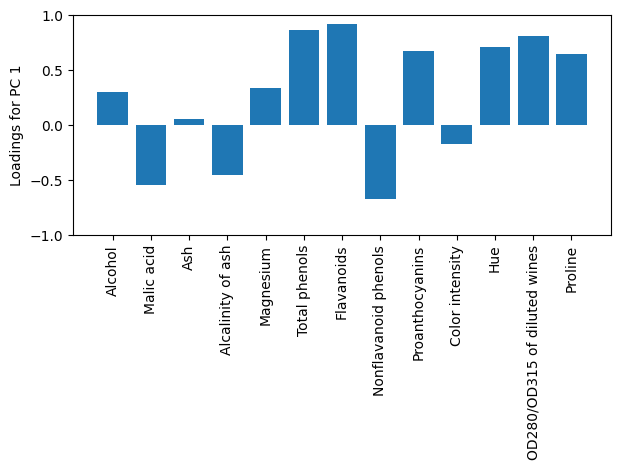

In [16]:
# Аналогичным образом мы можем получить нагрузки из обученного объекта РСА scikit-leam, где pca.components_
# представляет собственные векторы, а рса.explained_variance_ представляет собственные значения:
sklearn_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
fig, ax = plt.subplots()
ax.bar(range(13), sklearn_loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)
plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

### 5.2. Сжатие данных с учителем с помощью линейного дискриминантного анализа (linear discriminant analysis) LDA

In [17]:
# Алгоритм LDA можно использовать для извлечения признаков в качестве метода, который способствует
# повышению эффективности вычислений и уменьшению риска переобучения из-за проклятия размерности в
# нерегуляризованных моделях. В целом идея LDA очень похожа на РСА, но в то время как РСА ищет оси
# ортогональных компонент максимальной дисперсии в наборе данных, цель LDA состоит в том, чтобы найти
# подпространство признаков, которое оптимизирует разделимость классов. В следующих
# разделах мы более подробно обсудим сходство между LDA и РСА и шаг за шагом исследуем подход LDA.

#### 5.2.1. Сравнение методов РСА и LDA

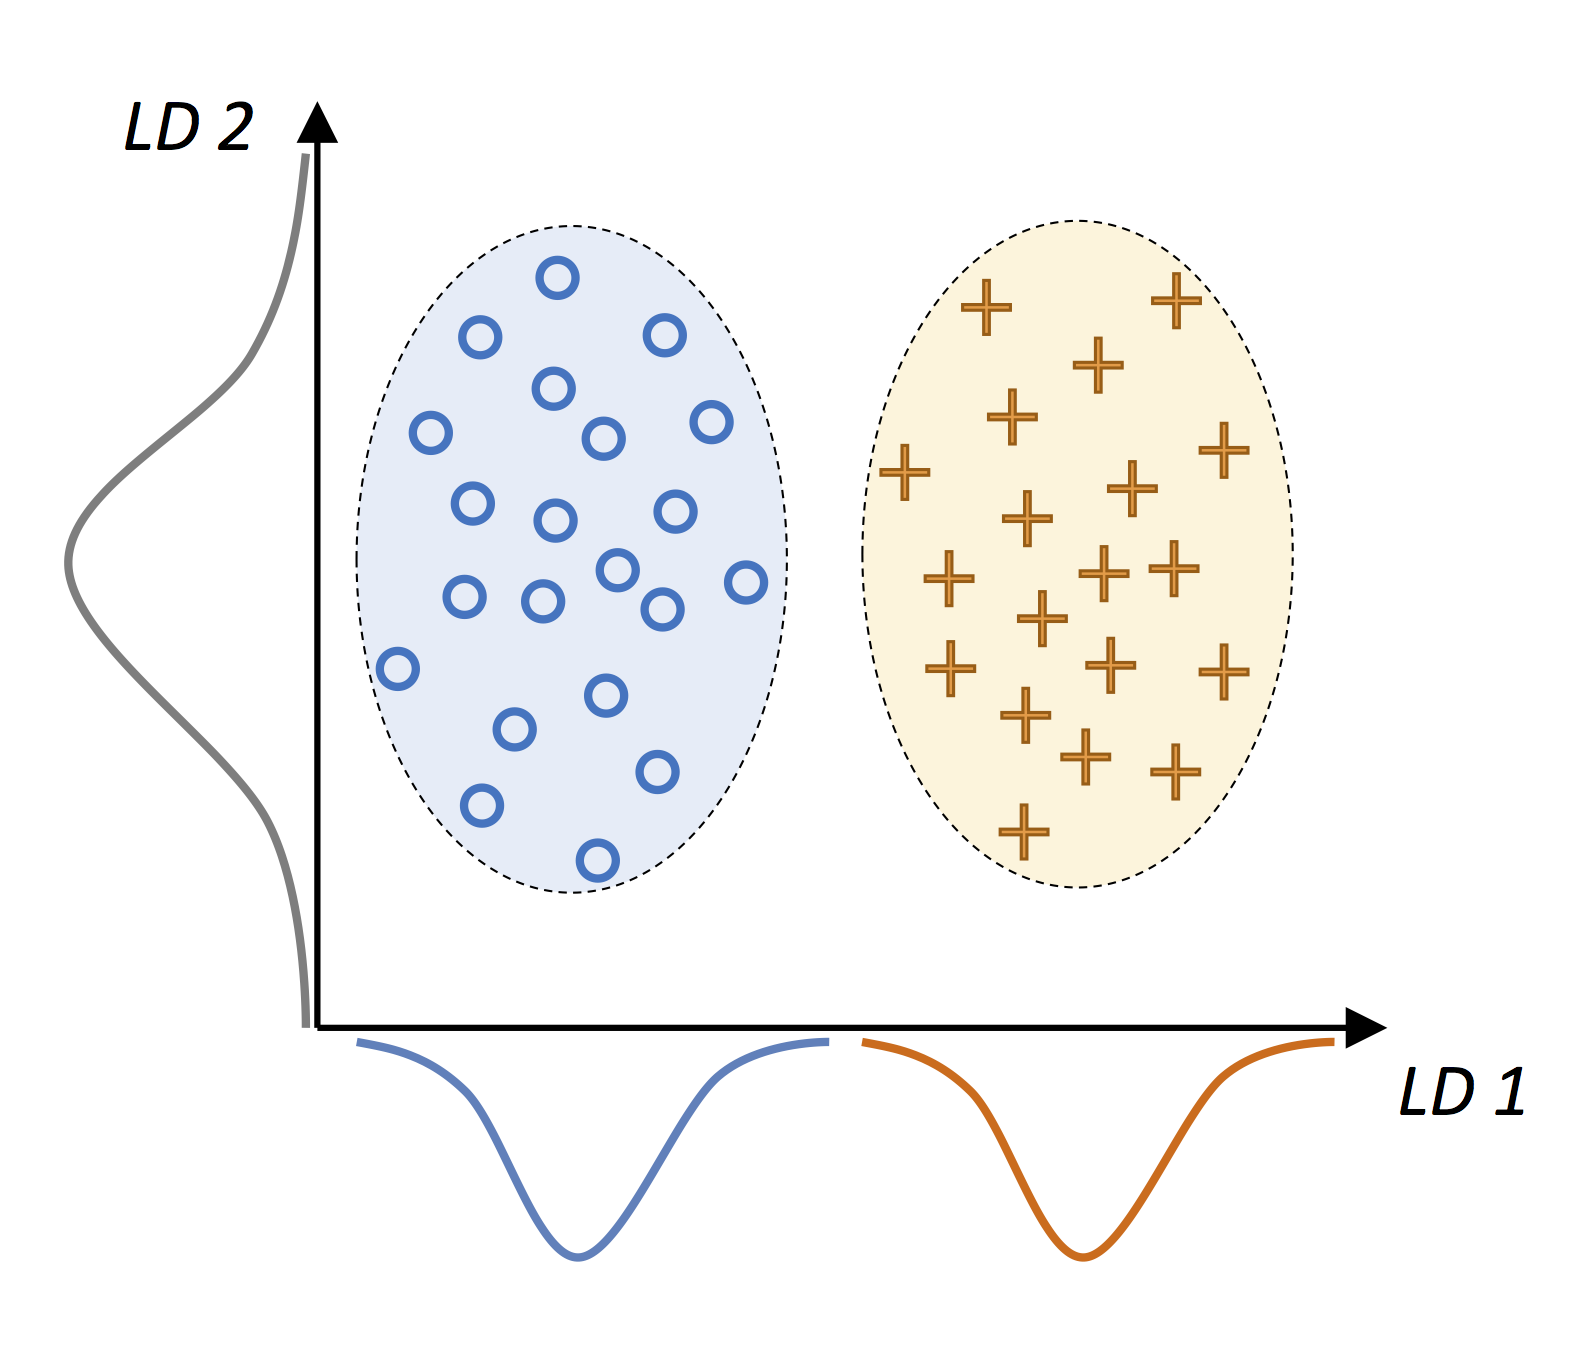

In [18]:
Image(filename='figures/05_06.png', width=400)
# И РСА, и LDA представляют собой линейные преобразования, которые применяют для
# уменьшения количества измерений в наборе данных: первый является алгоритмом без
# учителя, а второй - с учителем. Мы можем сделать поспешный вывод, что LDA - это
# заведомо лучший метод извлечения признаков для задач классификации по сравнению
# с РСА. Однако А. М. Мартинес установил, что в определенных случаях предварительная обработка с помощью РСА способна давать лучшие результаты классификации
# в задаче распознавания изображений, например если каждый класс состоит только из
# небольшого числа экземпляров) .

#### 5.2.2. Как устроен алгоритм LDA? 

In [19]:
# Прежде чем мы углубимся в реализацию кода, давайте кратко обобщим основные шаги, необходимые для выполнения LDA:
# 1. Стандартизируйте d-мерный набор данных (d- количество признаков).
# 2. Для каждого класса вычислите d-мерный средний вектор.
# 3. Постройте матрицу межклассового разброса и матрицу внутриклассового разброса.
# 4. Вычислите собственные векторы и соответствующие собственные значения матрицы.
# 5. Отсортируйте собственные значения в порядке убывания, чтобы ранжировать соответствующие собственные векторы.
# 6. Выберите k собственных векторов, соответствующих k наибольшим собственным значениям, чтобы построить
# k-мерную матрицу преобразования W, где собственные векторы являются столбцами этой матрицы.
# 7. Спроецируйте экземпляры набора данных на подпространство новых признаков, используя матрицу преобразования W.
# Как видите, LDA очень похож на РСА в том смысле, что мы разлагаем матрицы на собственные значения и
# собственные векторы, которые образуют новое пространство признаков меньшей размерности . Однако, как было
# сказано ранее, LDA учитывает информацию о метках классов, которая представлена в виде средних векторов,
# вычисленных на шаге 2. В следующих разделах мы обсудим эти семь шагов более подробно, иллюстрируя их
# фрагментами кода.

#### 5.2.3 Вычисление матриц разброса 

In [20]:
# Поскольку мы уже стандартизировали признаки набора данных Wine в разд. 5.1.2, то можем пропустить первый шаг и
# перейти к вычислению средних векторов, которые будем использовать для построения матриц внутриклассового и
# межклассового разброса. Каждый средний вектор т, хранит среднее значение признака µт по отношению к экземплярам
# класса i:
np.set_printoptions(precision=4)
# устанавливает, что при выводе массивов NumPy на экран, числа с плавающей точкой будут отображаться
# с 4 знаками после десятичной запятой
mean_vecs = []
for label in range(1, 4):
    mean_vecs.append(np.mean(X_train_std[y_train == label], axis=0))
    print(f'MV {label}: {mean_vecs[label - 1]}\n')

MV 1: [ 0.9066 -0.3497  0.3201 -0.7189  0.5056  0.8807  0.9589 -0.5516  0.5416
  0.2338  0.5897  0.6563  1.2075]

MV 2: [-0.8749 -0.2848 -0.3735  0.3157 -0.3848 -0.0433  0.0635 -0.0946  0.0703
 -0.8286  0.3144  0.3608 -0.7253]

MV 3: [ 0.1992  0.866   0.1682  0.4148 -0.0451 -1.0286 -1.2876  0.8287 -0.7795
  0.9649 -1.209  -1.3622 -0.4013]



In [21]:
# Используя средние векторы, мы теперь можем вычислить матрицу внутриклассового разброса путем суммирования
# отдельных матриц разброса Si, каждого отдельного класса i:
# Si = sum((x-m)(x-m).T)

d = 13 # количество признаков
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.zeros((d, d))
    for row in X_train_std[y_train == label]:
        row, mv = row.reshape(d, 1), mv.reshape(d, 1)
        class_scatter += (row - mv).dot((row - mv).T)
    S_W += class_scatter

print('Within-class scatter matrix: '
      f'{S_W.shape[0]}x{S_W.shape[1]}')

Within-class scatter matrix: 13x13


In [22]:
# Предположение, которое мы делаем при вычислении матриц разброса, состоит в том, что метки классов в обучающем
# наборе данных распределены равномерно. Однако если мы выведем на печать количество меток класса, то увидим,
# что это предположение нарушается:
print('Распределение меток класса:',
      np.bincount(y_train)[1:])

Распределение меток класса: [41 50 33]


In [23]:
# Следовательно, мы должны масштабировать отдельные матрицы разброса Si, прежде чем суммировать их как матрицу
# разброса Sw. Разделив матрицы разброса на количество экземпляров классов п мы видим, что вычисление матрицы
# разброса фактически совпадает с вычислением ковариационной матрицы - поскольку ковариационная матрица
# представляет собой нормализованную версию матрицы разброса:
d = 13
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.cov(X_train_std[y_train == label].T)
    S_W += class_scatter

print('Масшт. матрица внутриклассового разброса: '
      f'{S_W.shape[0]}x{S_W.shape[1]}')

Масшт. матрица внутриклассового разброса: 13x13


In [24]:
# После вычисления масштабированной матрицы внутриклассового разброса (или ковариационной матрицы) мы можем
# перейти к следующему шагу и вычислить матрицу межклассового разброса Sb:
# Sb = sum(ni(mi-m)(mi-m).T),
# где т - вычисленное общее среднее значение, включающее экземпляры из всех классов с:

mean_overall = np.mean(X_train_std, axis=0)
mean_overall = mean_overall.reshape(d, 1)

d = 13
S_B = np.zeros((d, d))

for i, mean_vec in enumerate(mean_vecs):
    n = X_train_std[y_train == i + 1, :].shape[0]
    mean_vec = mean_vec.reshape(d, 1)
    S_B += n * (mean_vec - mean_overall).dot((mean_vec - mean_overall).T)

print('Maтpицa межклассового разброса: '
      f'{S_B.shape[0]}x{S_B.shape[1]}')

Maтpицa межклассового разброса: 13x13


#### 5.2.4. Выбор линейных дискриминантов для нового подпространства признаков 

Остальные шаги LDA аналогичны шагам РСА. Однако вместо того, чтобы выполнять собственное разложение ковариационной матрицы, мы решаем обобщенную задачу нахождения собственных значений матрицы $S_W^{-1}S_B$:

In [25]:
eigen_vals, eigen_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

После нахождения собственных пар вектор-значение мы можем отсортировать собственные значения в порядке убывания: 

In [26]:
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]

eigen_pairs = sorted(eigen_pairs, key=lambda k: k[0], reverse=True)

print('Собственные значения по убыванию:\n')
for eigen_val in eigen_pairs:
    print(eigen_val[0])

Собственные значения по убыванию:

349.61780890599397
172.7615221897938
3.2778759481604224e-14
2.842170943040401e-14
2.6347620763320892e-14
2.6347620763320892e-14
1.7169492680170284e-14
1.7169492680170284e-14
1.674335053365994e-14
1.2740060380615559e-14
7.458378098449663e-15
4.7370485570543226e-15
3.6888431873149695e-15


Чтобы измерить, какая часть информации о разделении классов извлекается линейными дискриминантами (собственными векторами), построим линейные дискриминанты по убыванию собственных значений, подобно диаграмме объясненной дисперсии, которую мы ранее создали для РСА. Для удобства назовем содержание информации о разделении классов разделимостью, или - ближе к ее английской транскрипции - дискриминируемостью (discriminaЬility): 

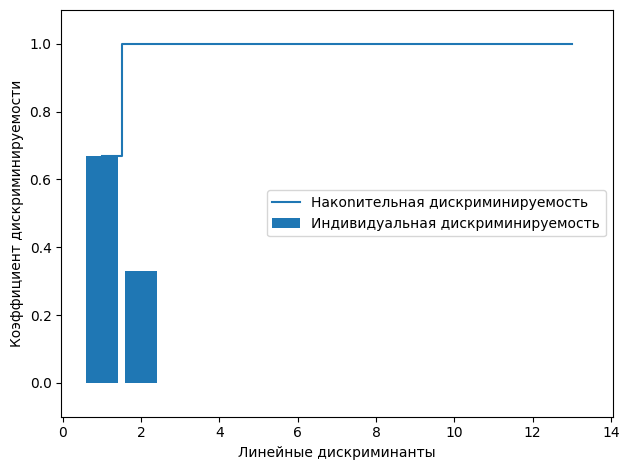

In [27]:
tot = sum(eigen_vals.real)
discr = [(i / tot) for i in sorted(eigen_vals.real, reverse=True)]
cum_discr = np.cumsum(discr)

plt.bar(range(1, 14), discr, align='center',
        label='Индивидуальная дискриминируемость')
plt.step(range(1, 14), cum_discr, where='mid',
         label='Накоnительная дискриминируемость')
plt.ylabel('Коэффициент дискриминируемости')
plt.xlabel('Линейные дискриминанты')
plt.ylim([-0.1, 1.1])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Теперь объединим два наиболее дискриминируемых столбца собственных векторов, чтобы создать матрицу преобразования: 

In [28]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis].real,
              eigen_pairs[1][1][:, np.newaxis].real))
print('Matrix W:\n', w)

Matrix W:
 [[-0.1481 -0.4092]
 [ 0.0908 -0.1577]
 [-0.0168 -0.3537]
 [ 0.1484  0.3223]
 [-0.0163 -0.0817]
 [ 0.1913  0.0842]
 [-0.7338  0.2823]
 [-0.075  -0.0102]
 [ 0.0018  0.0907]
 [ 0.294  -0.2152]
 [-0.0328  0.2747]
 [-0.3547 -0.0124]
 [-0.3915 -0.5958]]


#### 5.2.5. Проецирование точек данных на новое функциональное пространство 

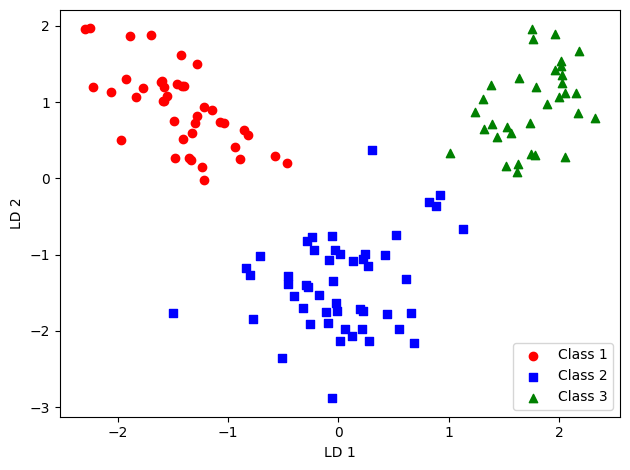

In [29]:
X_train_lda = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_lda[y_train == l, 0],
                X_train_lda[y_train == l, 1] * (-1),
                c=c, label=f'Class {l}', marker=m)

plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### 5.2.6. Реализация LDA при помощи scikit-learn 

В качестве примера посмотрим, как классификатор лоrистической регрессии обрабатывает набор обучающих данных с низкой размерностью после преобразования LDA: 

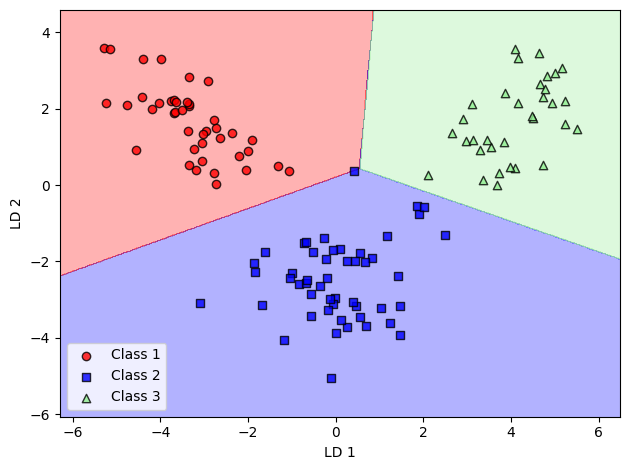

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

base_lr = LogisticRegression(random_state=1, solver='lbfgs')
lr = OneVsRestClassifier(base_lr)
lr = lr.fit(X_train_lda, y_train)

plot_decision_regions(X_train_lda, y_train, classifier=lr)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

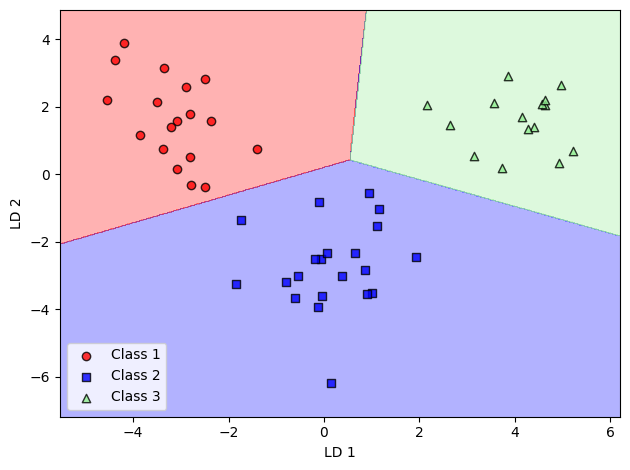

In [31]:
X_test_lda = lda.transform(X_test_std)
plot_decision_regions(X_test_lda, y_test, classifier=lr)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Как мы видим на рис. 5.12, классификатор логистической регрессии может с идеальной точностью классифицировать экземпляры в тестовом наборе данных, используя только двумерное подпространство признаков вместо исходных 13 признаков Wine.

### 5.3. Нелинейное уменьшение размерности и визуализация 

В предыдущем разделе мы рассмотрели методы извлечения признаков на основе линейных преобразований РСА и LDA. Далее мы обсудим, почему иногда может оказаться полезным нелинейное уменьшение размерности. Один из методов нелинейного уменьшения размерности, на который стоит обратить особое внимание, - это t-распределенное стохастическое встраивание соседей (t-distributed Stochastic Neighbor Embedding, t-SNE), поскольку он часто используется
в литературе для визуализации многомерных наборов данных в двух или трех измерениях. Мы рассмотрим пример применения t-SNE для построения диаграммы распределения изображений рукописных цифр в двумерном пространстве признаков. 

#### 5.3.1. Зачем рассматривать нелинейное уменьшение размерности? 

Многие алгоритмы машинного обучения делают предположения о линейной разделимости входных данных. Так, вы уже знаете, что для сходимости персептрону требуются идеально линейно разделимые обучающие данные. Другие алгоритмы, которые мы рассмотрели до сих пор, предполагают, что отсутствие идеальной линейной разделимости связано с шумом: Adaline, логистическая регрессия и стандартный SVM - это лишь некоторые из них.
Однако, если вам доведется иметь дело с нелинейными задачами, которые довольно часто встречаются в реальной жизни, методы линейного преобразования для уменьшения размерности, такие как РСА и LDA, могут оказаться не лучшим выбором 

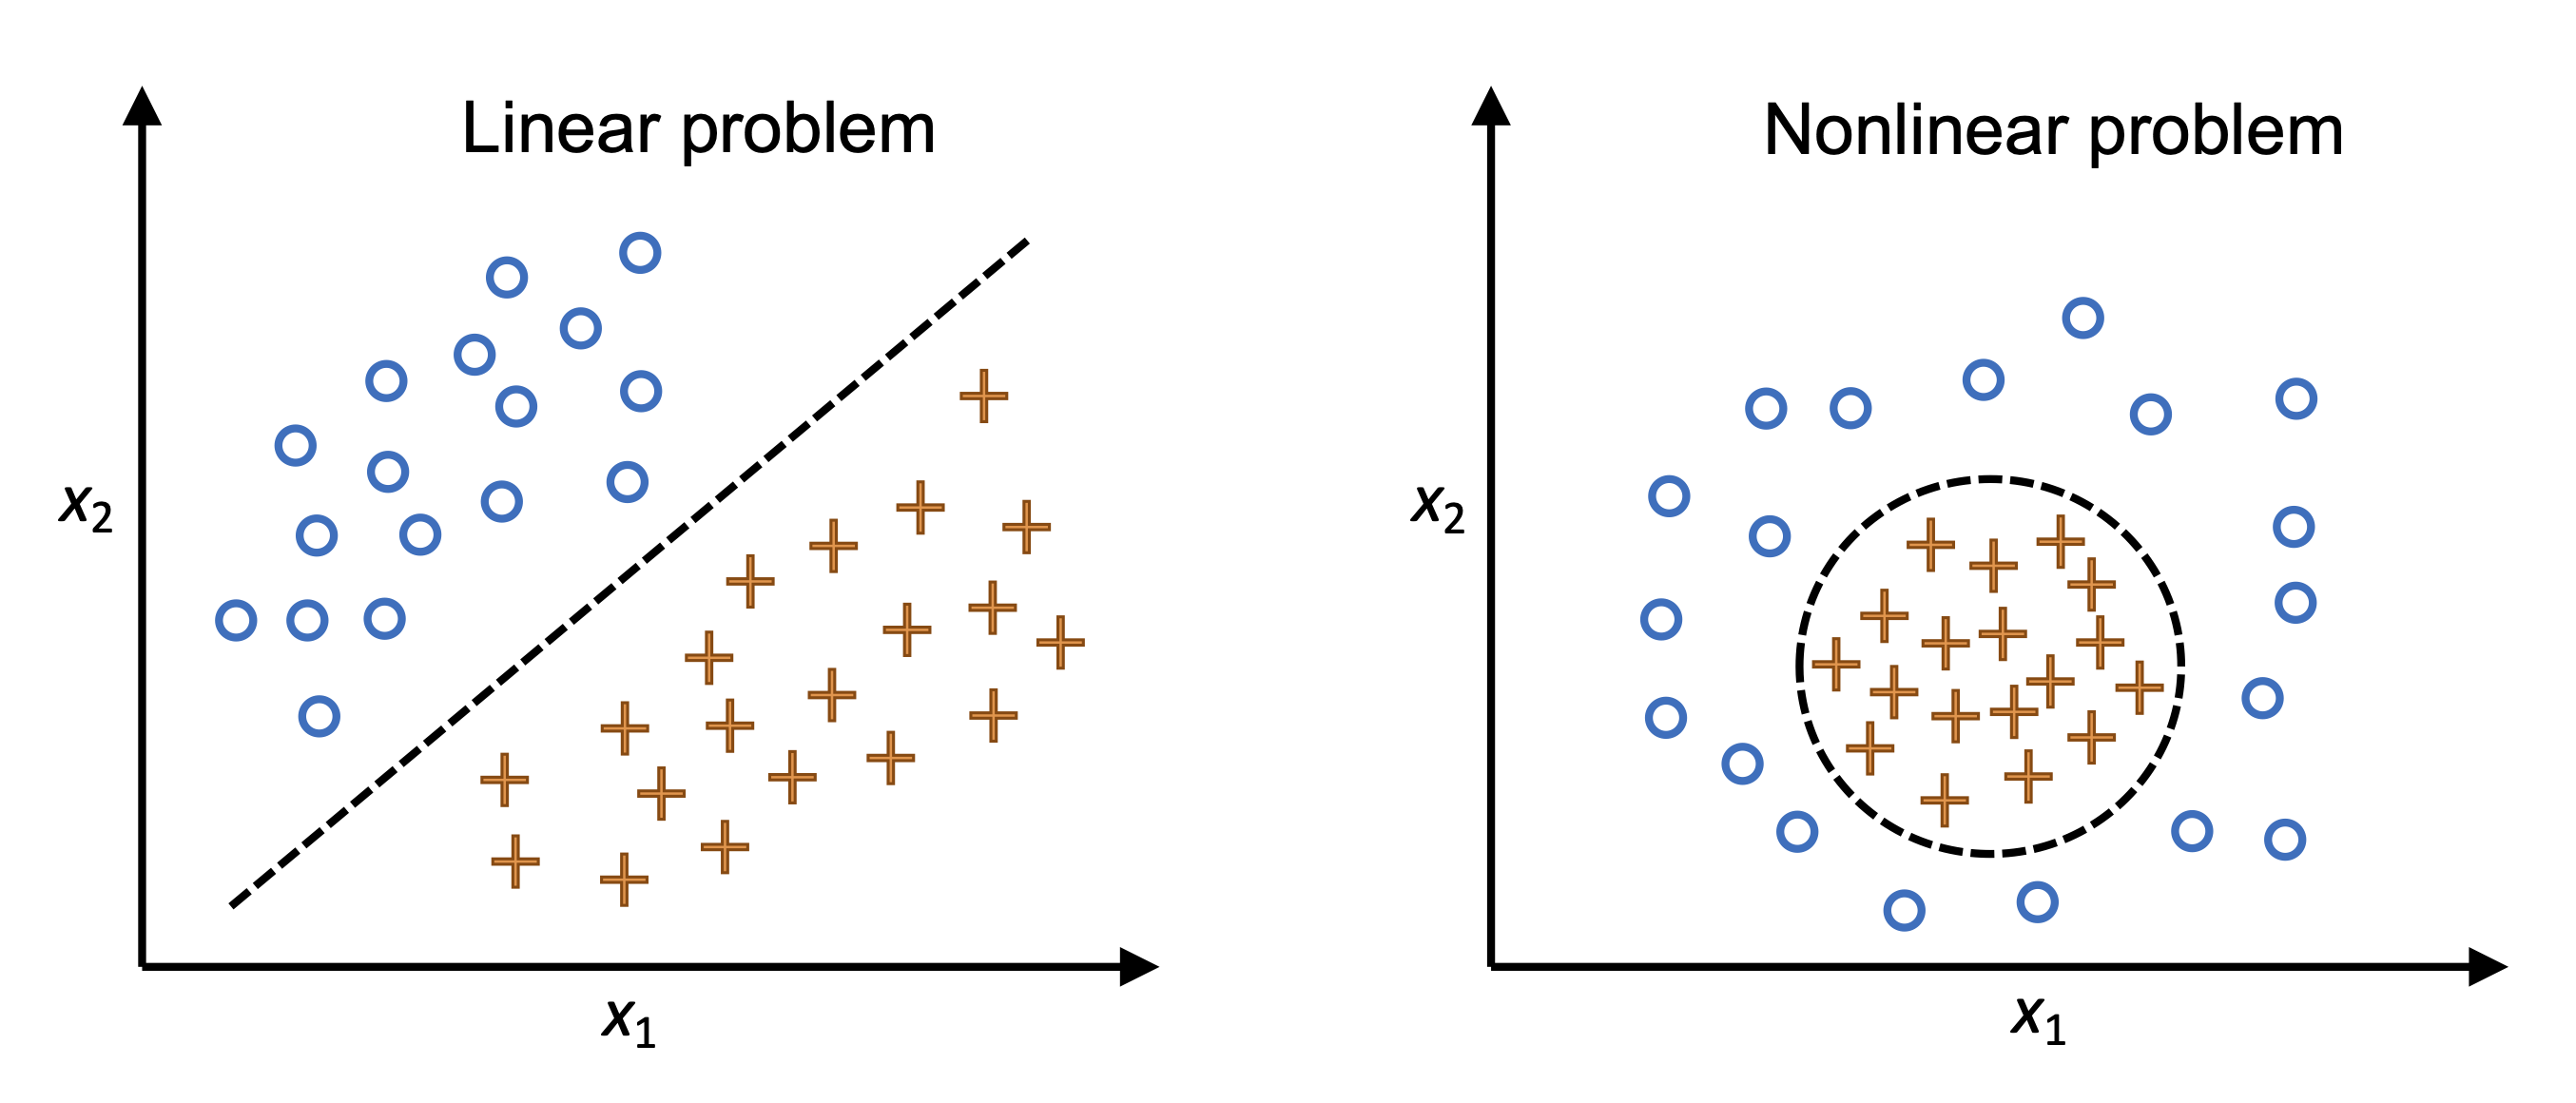

In [32]:
Image(filename='figures/05_11.png', width=500)

Разработку и применение методов нелинейного уменьшения размерности также часто называют обучением на основе многообразий (manifold leaming), где многообразие означает встраивание топологического пространства более низкой размерности в многомерное пространство. Алгоритмы обучения на основе многообразий должны извлекать информацию о сложной структуре данных, чтобы спроецировать их на пространство с меньшими размерностями, где сохраняется связь между точками данных.
Классическим примером обучения на основе многообразий является фигура трехмерного «швейцарского рулета», показанная на рис. 5.14. 

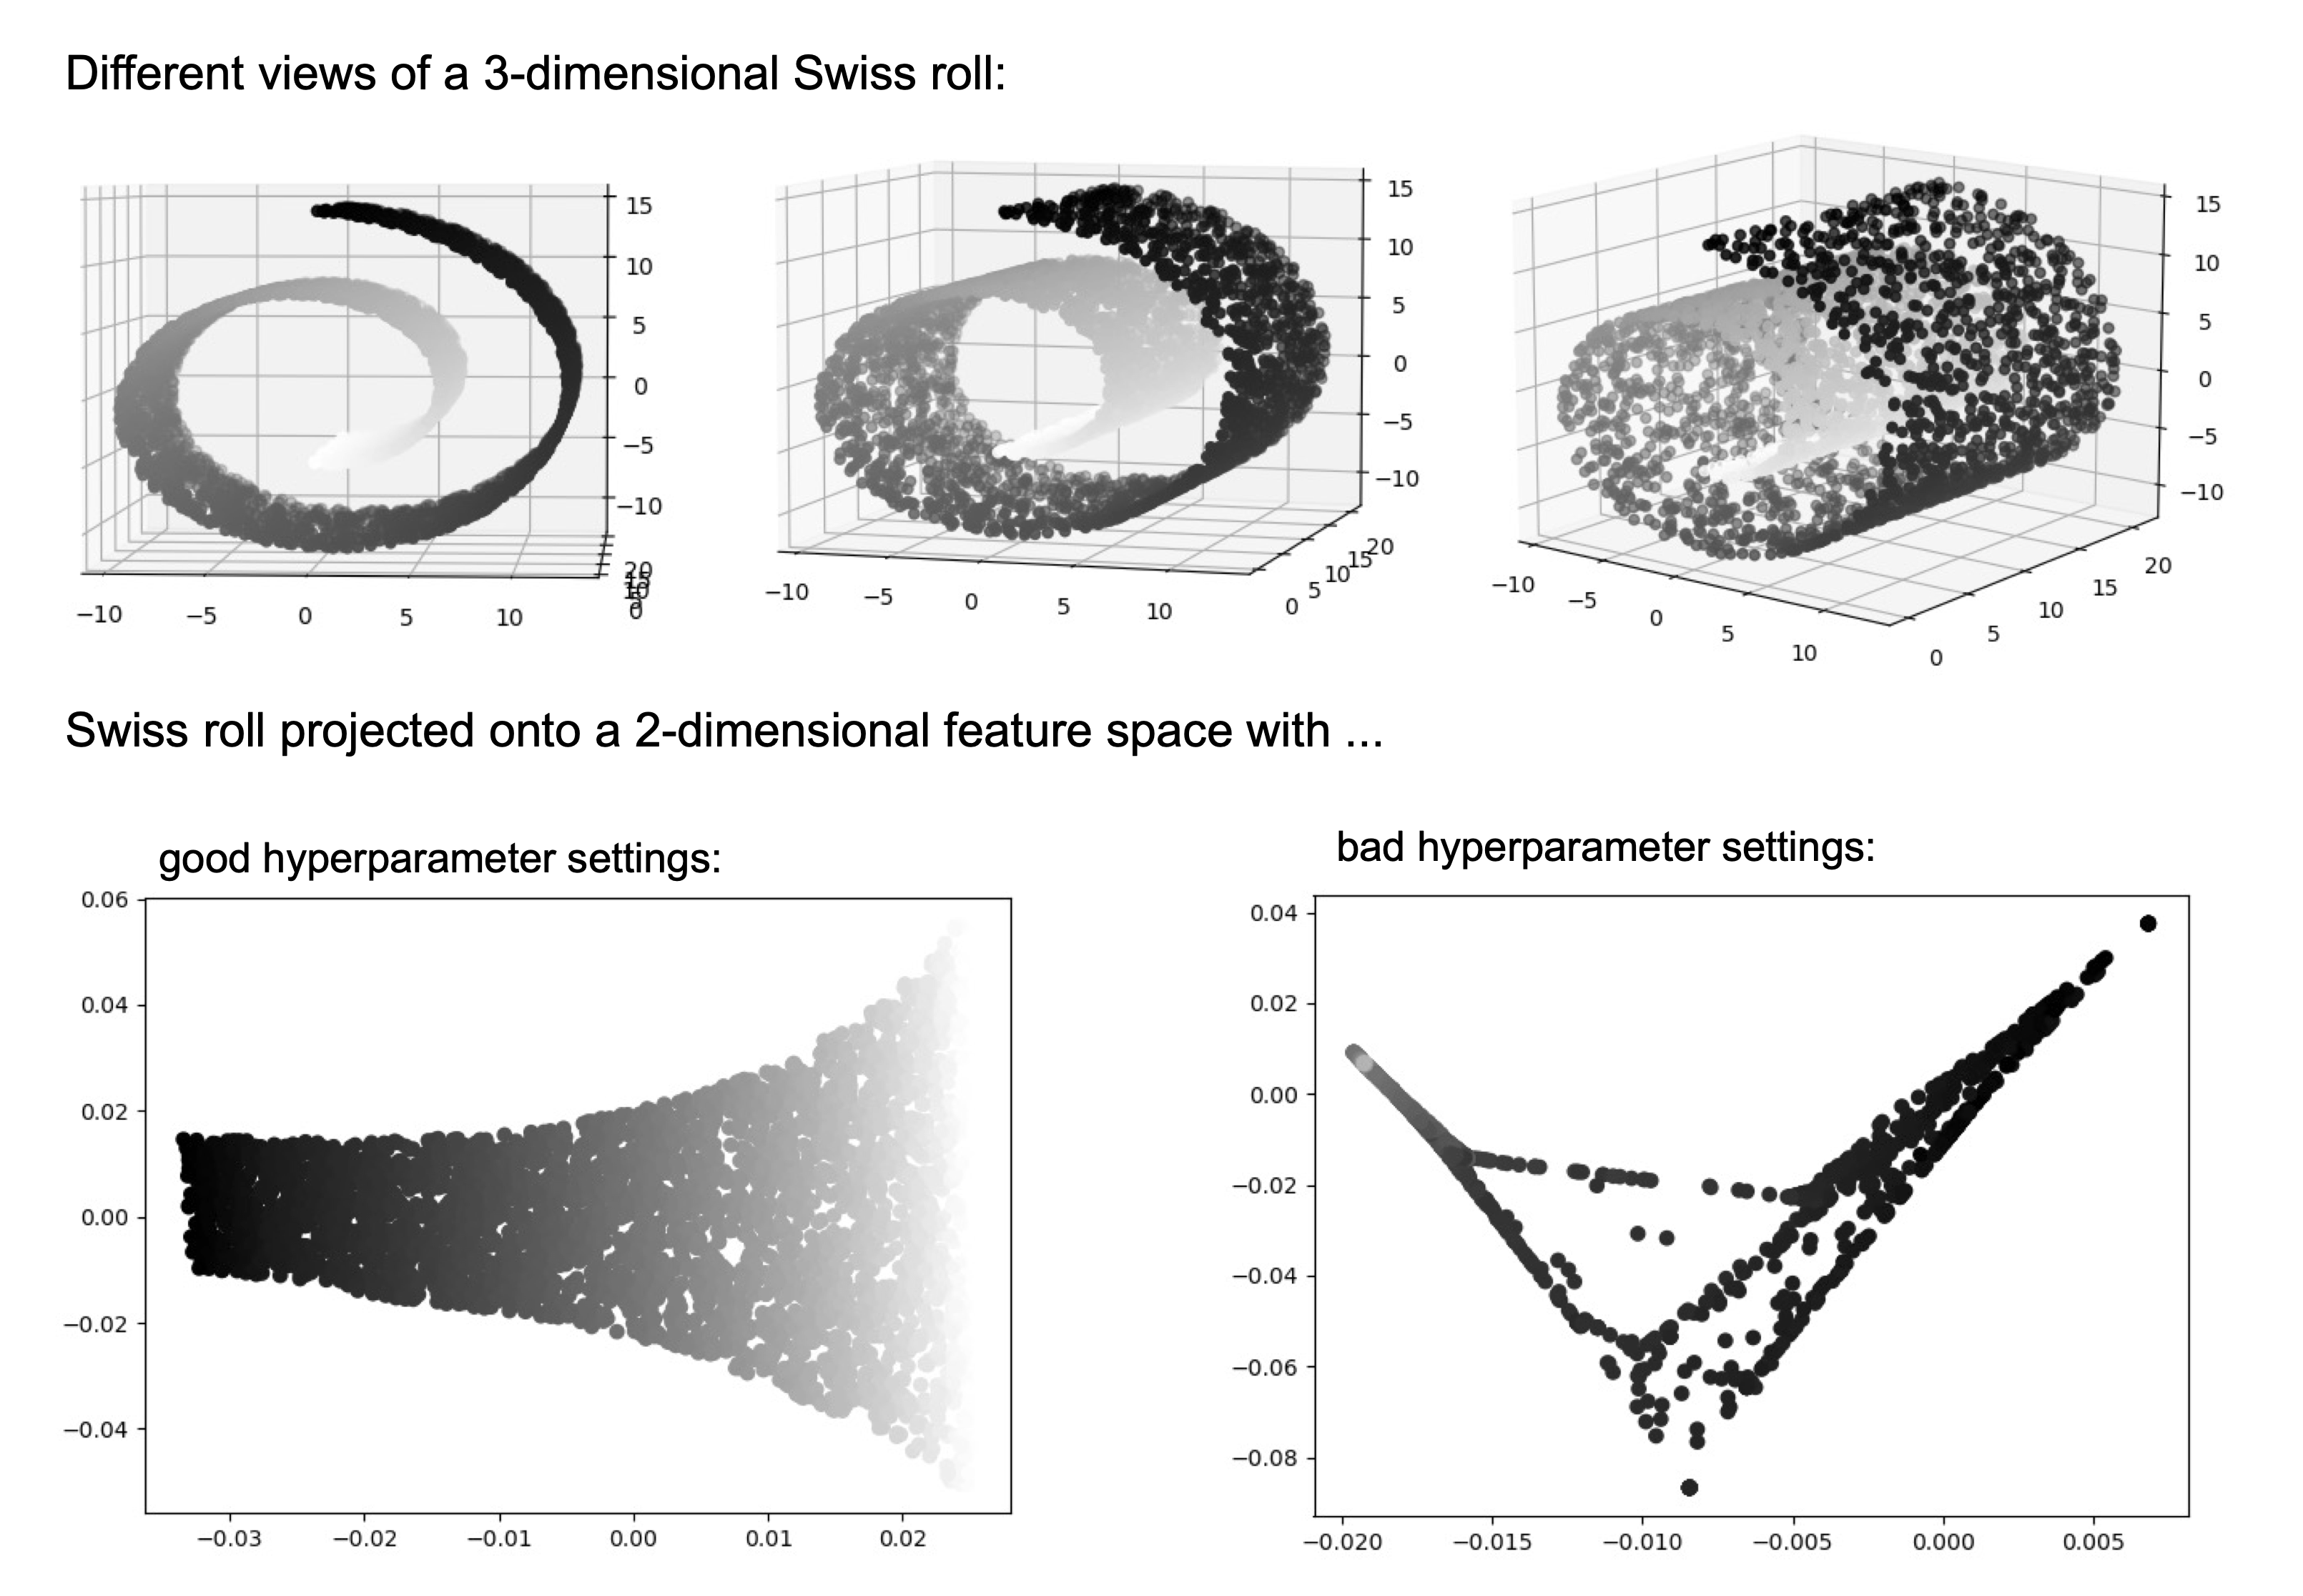

In [33]:
Image(filename='figures/05_14.png', width=600)

Хотя алгоритмы нелинейного уменьшения размерности и обучения на основе многообразия очень эффективны, необходимо отметить, что эти методы сложны в использовании, а при неудачном выборе гиперпараметров могут причинить больше вреда, чем пользы. Дело в том, что мы часто работаем с многомерными наборами данных, которые
не можем легко визуализировать и структура которых не очевидна (в отличие от примера с рулетом на рис. 5.14). Более того, если мы не спроецируем набор данных в два или три измерения (чего часто недостаточно для сохранения более сложных взаимосвязей), трудно или даже невозможно оценить качество результатов. По этой причине
многие пользователи по-прежнему полагаются на более простые методы уменьшения
размерности, такие как РСА и LDA. 

#### 5.3.2. Визуализация данных с помощью алгоритма t-SNE 

Если коротко, t-SNE моделирует точки данных на основе их попарных расстояний в многомерном (исходном) пространстве признаков. Затем он находит распределение вероятностей парных расстояний в новом пространстве меньшей размерности, которое близко к распределению вероятностей парных расстояний в исходном пространстве. Или, другими словами, t-SNE учится встраивать точки данных в пространство более низкой размерности, так что попарные расстояния в исходном пространстве сохраняются. Однако нельзя забывать, что t-SNE- это метод визуализации, которому для проекции требуется весь набор данных. Поскольку он проецирует точки напрямую (в отличие от РСА, он не использует матрицу проекции), мы не можем применить t-SNE к новым точкам данных.
Следующий код представляет собой пример применения t-SNE к 64-мерному набору
данных. Мы начинаем с загрузки набора данных Digits из scikit-leam, кокоторый состоит
из изображений рукописных цифр с низким разрешением (цифры 0-9):

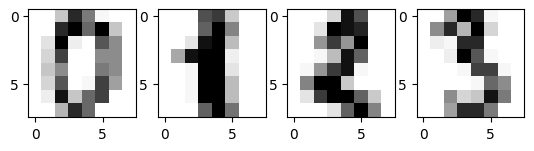

In [34]:
# Цифры представляют собой изображения 8х8 в градациях серого. Следующий код отображает первые четыре изображения
# в наборе данных, который в общей сложности состоит из 1797 изображений:
from sklearn.datasets import load_digits
digits = load_digits()
fig, ax = plt.subplots(1, 4)
for i in range(4):
    ax[i].imshow(digits.images[i], cmap='Greys')
plt.show()

In [35]:
digits.data.shape

(1797, 64)

In [36]:
# Далее присвоим признаки (пикселы) новой переменной x_digits, а метки - другой новой переменной y_digits:
y_digits = digits.target
X_digits = digits.data

In [37]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2,
            init='pca',
            random_state=123)
X_digits_tsne = tsne.fit_transform(X_digits)

Выполнив этот код, мы спроецировали 64-мерный набор данных на двумерное пространство. Мы указали здесь параметр ini t= 'рса', который инициализирует встраивание t-SNE с использованием РСА, как это рекомендуется в статье Кабака и Линдермана. Нужно отметить, что у t-SNE есть дополнительные rиперпараметры - такие как перплексия и скорость обучения (часто называемая эпсилон), которые мы пропустили в примере (точнее, использовали значения scikit-learn по умолчанию). На практике мы рекомендуем вам изучить и эти параметры • Наконец, визуализируем 2D-встраивания
t-SNE, используя следующий код: 

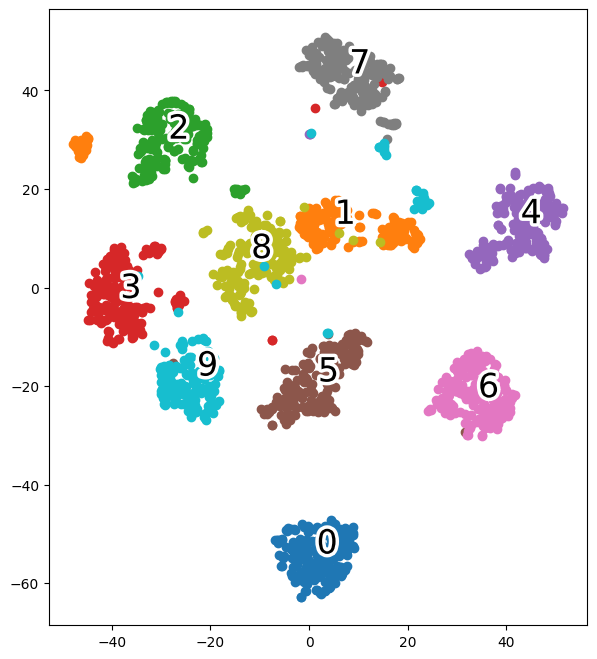

In [38]:
import matplotlib.patheffects as PathEffects
def plot_projection(x, colors):

    f = plt.figure(figsize=(8, 8))
    ax = plt.subplot(aspect='equal')
    for i in range(10):
        plt.scatter(x[colors == i, 0],
                    x[colors == i, 1])

    for i in range(10):

        xtext, ytext = np.median(x[colors == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects([
            PathEffects.Stroke(linewidth=5, foreground="w"),
            PathEffects.Normal()])

plot_projection(X_digits_tsne, y_digits)
plt.show()

Как и РСА, метод t-SNE обучается без учителя, и в приведенном коде мы используем метки класса y_digits (0-9) только для целей визуализации, передавая функции аргумент цвета. Для наглядности применяется метод PathEffects из Matplotlib, так что метка класса отображается в центре группы точек данных, принадлежащих каждой соответствующей цифре (через np.mectian). Построенная при помощи этого кода диаграмма рассеяния представлена на рис. 5.16.
Мы видим, что t-SNE довольно хорошо, хотя и не идеально, разделяет разные цифры (классы изображений). Можно добиться лучшего разделения, настроив rиперпараметры. Однако определенная степень смешения классов остается неизбежной из-за неразборчивого почерка. Например, изучая отдельные изображения, мы обнаружим, что некоторые экземпляры рукописной цифры 3 действительно похожи на 9, и т. д. 

# Заключение 

В этой главе вы узнали о двух фундаментальных методах уменьшения размерности для извлечения признаков: РСА и LDA. Используя РСА, мы проецировали данные на подпространство более низкого измерения, чтобы максимизировать дисперсию вдоль ортогональных осей признаков, игнорируя при этом метки классов. LDA, в отличие от РСА, представляет собой метод уменьшения размерности с учителем, т. е. учитывает информацию о классе в наборе обучающих данных, чтобы попытаться максимизировать разделимость классов в линейном пространстве признаков. В заключительной части главы
было рассказано о t-SNE - методе нелинейного извлечения признаков, который можно использовать для визуализации данных в двух или трех измерениях.
Вооружившись РСА и LDA в качестве основных методов предварительной обработки
данных, вы хорошо подготовились к тому, чтобы узнать в следующей главе о применении различных эффективных методов предварительной обработки и оценки производительности моделей. 